In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import locale
import seaborn as sns
import matplotlib.font_manager as fm


In [2]:
dataset = pd.read_csv('./SuperStoreOrders.csv')
pd.set_option('display.max_columns', None)  
locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')

'en_US.UTF-8'

In [3]:
dataset['sales'] = dataset['sales'].str.replace(',','.' )
dataset['sales'] = dataset['sales'].astype(float)

In [4]:
# catagorical columns

# region
#category
# sub_category
# ship_mode
# segment
# market

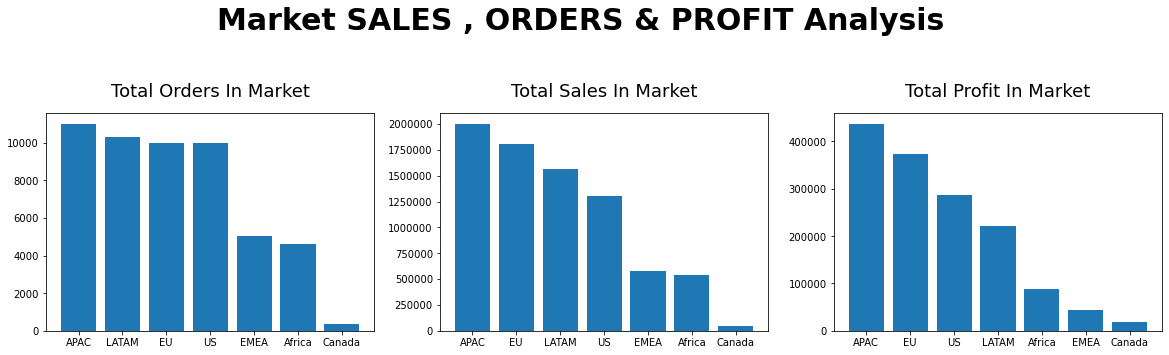

In [6]:
fig,[ax1,ax2,ax3] = plt.subplots(1,3,figsize=(20,4))

market_orders = dataset['market'].value_counts().sort_values(ascending=False) 
market_sales = dataset.groupby('market')['sales'].sum().sort_values(ascending=False)
market_profit = dataset.groupby('market')['profit'].sum().sort_values(ascending=False)



ax1.bar(market_orders.index , market_orders.values)

ax1.set_title('Total Orders In Market' , fontsize=18 ,  y=1.05)

ax2.bar(market_sales.index , market_sales.values)
ax2.set_title('Total Sales In Market' , fontsize=18 ,  y=1.05)
ax2.ticklabel_format(style='plain', axis='y', useOffset=False)


ax3.bar(market_profit.index , market_profit.values)
ax3.set_title('Total Profit In Market' , fontsize=18 ,  y=1.05)

plt.suptitle('Market SALES , ORDERS & PROFIT Analysis ' , fontsize=30 , y=1.25 , fontweight='bold')

plt.show()

In [7]:
def pie_profit_sales_quantity_analysis(ax,data,total_of):
    
    text_props = {'fontsize': 14 }
    title = 'Total {}'.format(total_of)
  
    ax.pie(data.values , labels=data.index  , colors = colors , autopct=lambda p:f'  {p:.1f}% \n {p*sum(data.values)/100 :.0f}' , pctdistance=0.7 , radius=1.3 , textprops=text_props)
    ax.set_title(title+'\n' + '_' * len(title), fontsize=17 ,  y=1.15 ,c='#242342' , fontweight='normal')
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)
    

    
    
def market_analysis_of_category(ax,data,total_of):
    
    explode = [0,0,0,0,0.5,0,1]
    text_props = {'fontsize': 11 }
    title = 'Total {}'.format(total_of)
  
    ax.pie(data.values , labels=data.index  ,explode=explode, colors = colors, autopct=lambda p:f'  {p:.1f}% \n {p*sum(data.values)/100 :.0f}' , pctdistance=0.7 , radius=1.3 , textprops=text_props)
    ax.set_title(title+'\n' + '_' * len(title), fontsize=17 ,  y=1.15 ,c='#242342' , fontweight='normal')
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)



def bar_chart_sales_profit_quantity_analysis(ax,data,total_of):
    
    title = 'Total '+total_of
    ax.barh(data.index , data.values , color=colors)
    ax.set_title(title+'\n' + '_' * len(title), fontsize=17 ,  y=1.15 ,c='#242342' , fontweight='normal')

In [8]:
def plot_market_des(ax,data,total_of):
    
    text_props = {'fontsize': 12 }
    title = 'Total {}'.format(total_of)
    total = sum(data.values)
    percentages = (data.values / total) * 100
    explode = []
    
    for i in percentages:
        if i <= 6:
            explode.append(0.6)
        else:
            explode.append(0)


  
    ax.pie(data.values , labels=data.index , explode=explode , colors = colors , autopct=lambda p:f'  {p:.1f}% \n {p*sum(data.values)/100 :.0f}' , pctdistance=0.7 , radius=1.3 , textprops=text_props)
    ax.set_title(title+'\n' + '_' * len(title), fontsize=17 ,  y=1.15 ,c='#242342' , fontweight='normal')
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)
    
    

# markets analysis for sub categories of category in profit
def each_market_analysis(market_data , market_name , inloss = False , bar=False):
    fig,[ax1,ax2,ax3] = plt.subplots(1,3,figsize=(20,5 if bar else 4))
    
    colors = sns.color_palette('pastel')[0:5]

    # market orders sales profit filter
    market_category_sold = market_data.groupby('sub_category')['quantity'].sum().sort_values(ascending=False)
    market_category_sales = market_data.groupby('sub_category')['sales'].sum().sort_values(ascending=False)
    market_category_profit = market_data.groupby('sub_category')['profit'].sum().sort_values(ascending=False)
    
    if (bar == False):
        # for quantity solds
        plot_market_des(ax1,market_category_sold,'Quantity Sold')

        # for Sales
        plot_market_des(ax2,market_category_sales,'Sales')


        # for Profit
        if (inloss):
            ax3.bar(market_category_profit.index , market_category_profit.values , color=colors)
            ax3.set_title('Total Profit'+'\n' + '_' * len('Total Profit'), fontsize=17 ,  y=1.15 ,c='#242342' , fontweight='normal')
        else:
            plot_market_des(ax3,market_category_profit,'Profit')
    
    else:
        bar_chart_sales_profit_quantity_analysis(ax1,market_category_sold , 'Quantity Sold')
        
        bar_chart_sales_profit_quantity_analysis(ax2,market_category_sales , 'Sales')
        
        bar_chart_sales_profit_quantity_analysis(ax3,market_category_profit , 'Profit')
        
    
    plt.suptitle('\n\n{} MARKET ANALYSIS'.format(market_name) , fontsize=24 , y=1.5 , fontweight='bold' , c='#fc685b')

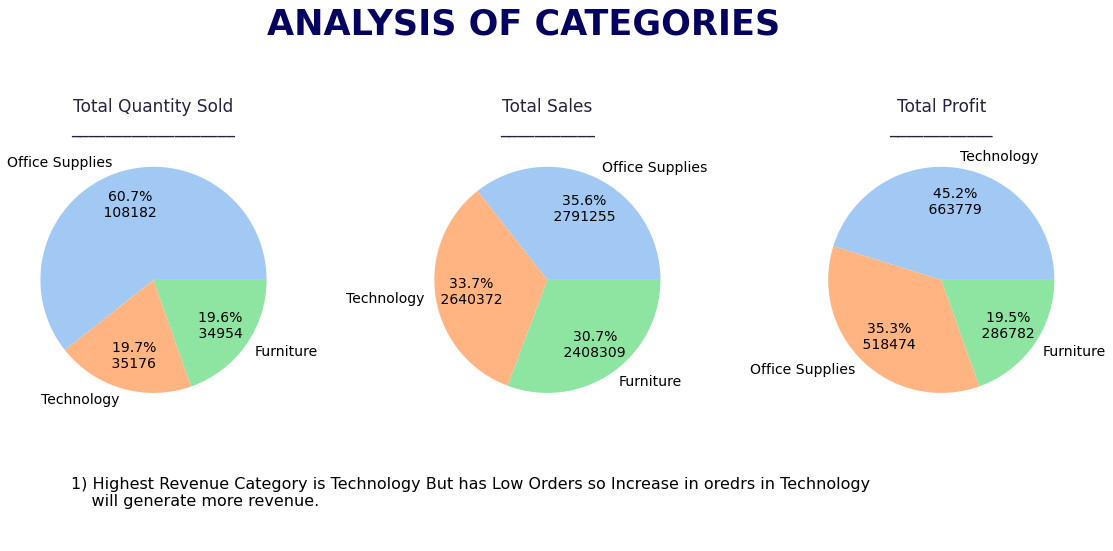

In [9]:

fig,[ax1,ax2,ax3] = plt.subplots(1,3,figsize=(20,4))

category_sold = dataset.groupby('category')['quantity'].sum().sort_values(ascending=False) 
category_sales = dataset.groupby('category')['sales'].sum().sort_values(ascending=False)
category_profit = dataset.groupby('category')['profit'].sum().sort_values(ascending=False)


# for category orders
pie_profit_sales_quantity_analysis(ax1,category_sold,'Quantity Sold')

# for category Sales
pie_profit_sales_quantity_analysis(ax2,category_sales,'Sales')


# for category Profit
pie_profit_sales_quantity_analysis(ax3,category_profit,'Profit')


txt = "1) Highest Revenue Category is Technology But has Low Orders so Increase in oredrs in Technology\n    will generate more revenue.\n\n"

plt.suptitle('ANALYSIS OF CATEGORIES ' ,fontsize=35 , y=1.45 , fontweight='bold' , c='#05015e')
plt.text(-10,-3 , s=txt , fontsize=16)

plt.show()

# TECHNOLOGY CATEGORY ANALYSIS

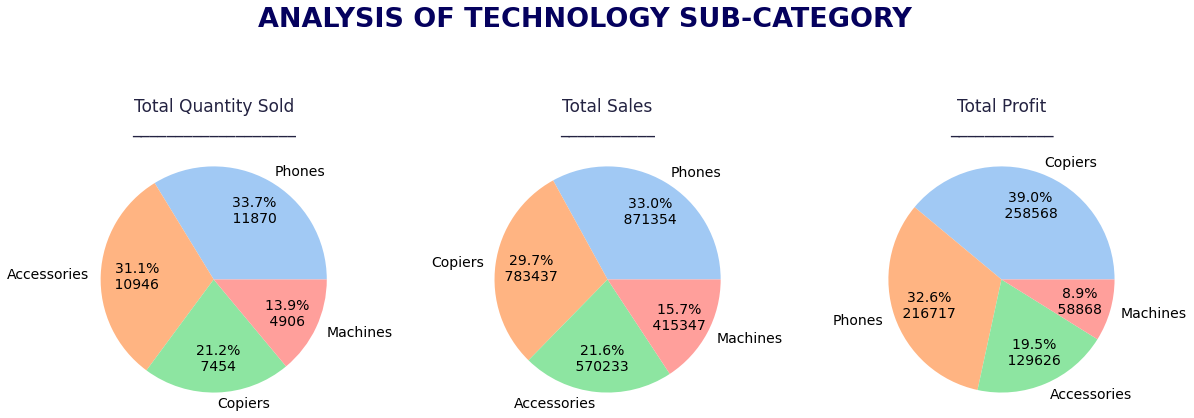

In [10]:
technology_data = dataset[dataset['category'] == 'Technology']

fig,[ax1,ax2,ax3] = plt.subplots(1,3,figsize=(20,4))

technology_solds = technology_data.groupby('sub_category')['quantity'].sum().sort_values(ascending=False)
technology_sales = technology_data.groupby('sub_category')['sales'].sum().sort_values(ascending=False)
technology_profit = technology_data.groupby('sub_category')['profit'].sum().sort_values(ascending=False)



# for technology orders
pie_profit_sales_quantity_analysis(ax1,technology_solds,'Quantity Sold')

# for technology Sales
pie_profit_sales_quantity_analysis(ax2,technology_sales,'Sales')


# for technology Profit
pie_profit_sales_quantity_analysis(ax3,technology_profit,'Profit')



plt.suptitle('ANALYSIS OF TECHNOLOGY SUB-CATEGORY ' , fontsize=27 , y=1.45 , fontweight='bold' , c='#05015e')

plt.show()

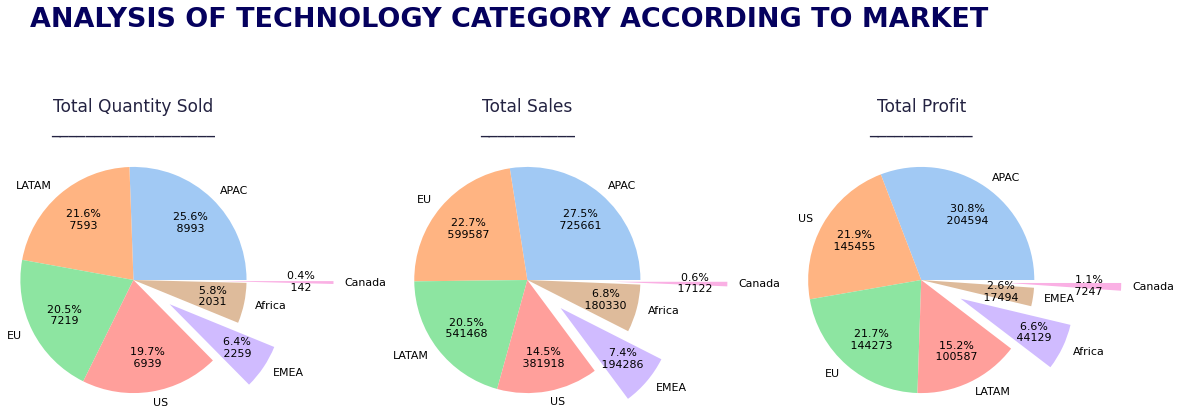

In [11]:
fig,[ax1,ax2,ax3] = plt.subplots(1,3,figsize=(20,4))

technology_market_solds = technology_data.groupby('market')['quantity'].sum().sort_values(ascending=False)
technology_market_sales = technology_data.groupby('market')['sales'].sum().sort_values(ascending=False)
technology_market_profit = technology_data.groupby('market')['profit'].sum().sort_values(ascending=False)


# for technology orders
market_analysis_of_category(ax1,technology_market_solds,'Quantity Sold')

# for technology Sales
market_analysis_of_category(ax2,technology_market_sales,'Sales')


# for technology Profit
market_analysis_of_category(ax3,technology_market_profit,'Profit')



plt.suptitle('ANALYSIS OF TECHNOLOGY CATEGORY ACCORDING TO MARKET' , fontsize=27 , y=1.45 , fontweight='bold' , c='#05015e')

plt.show()

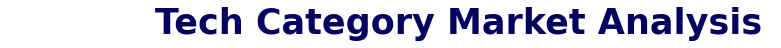

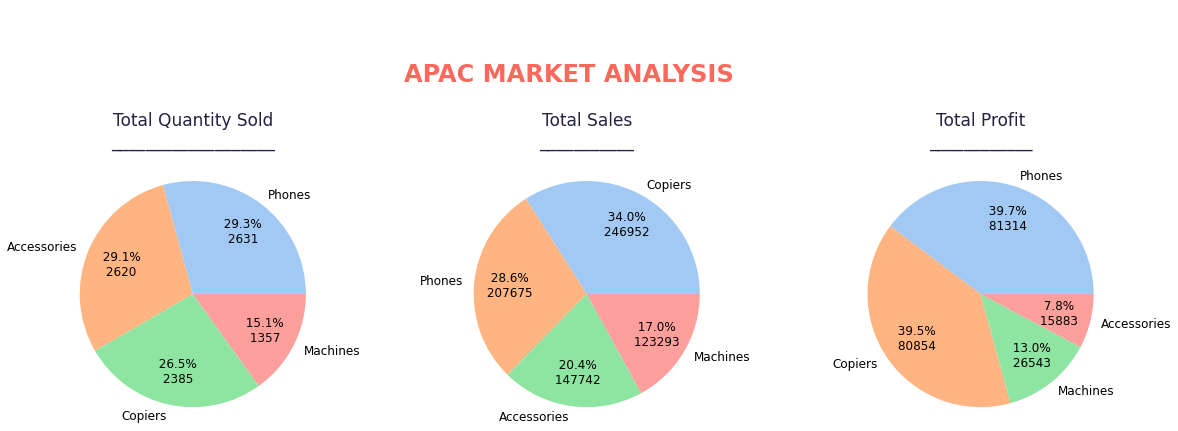

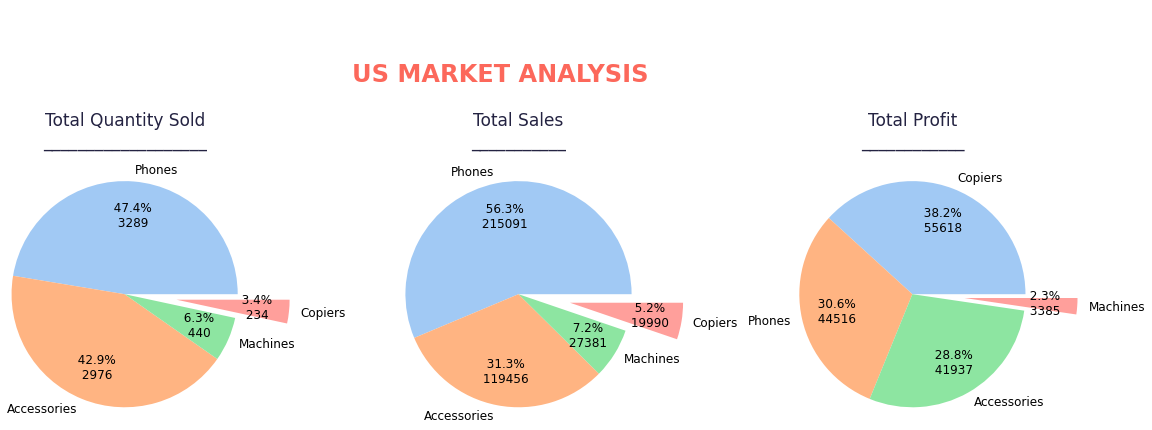

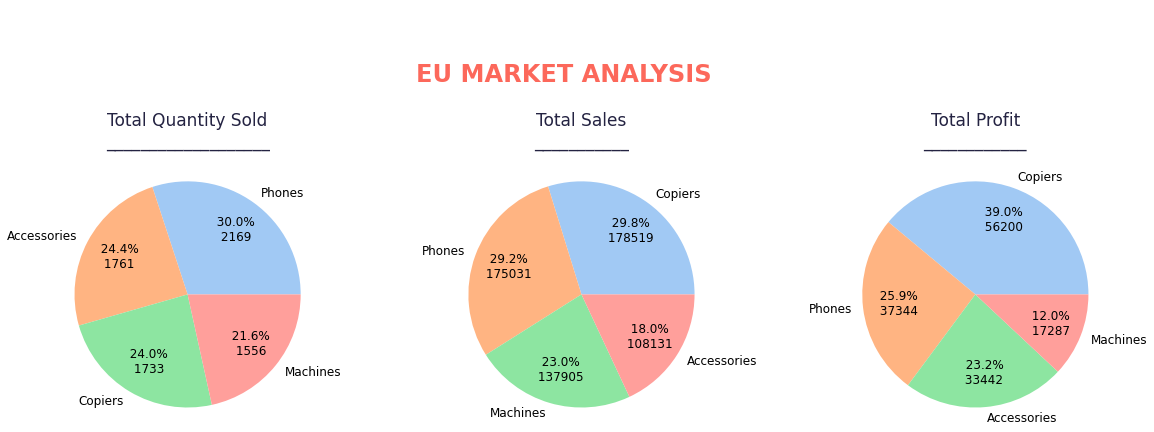

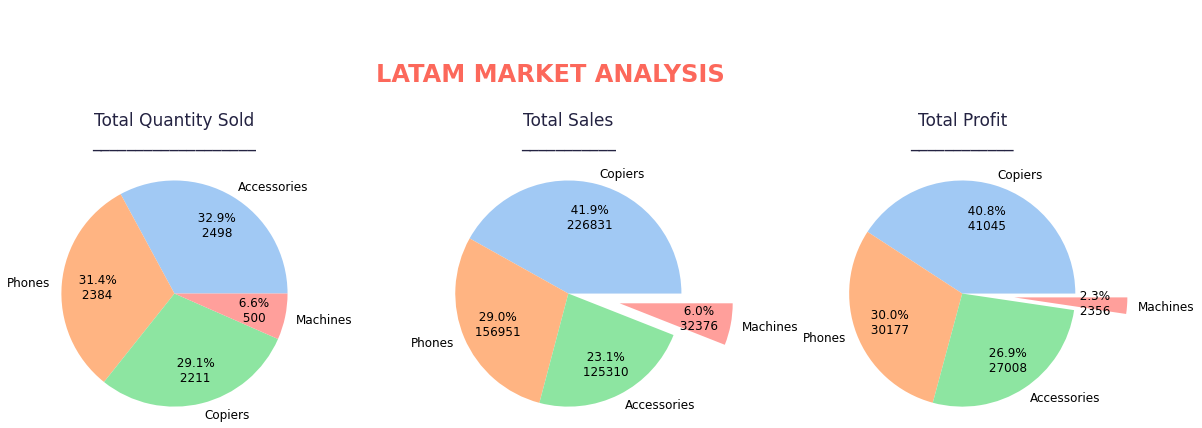

In [31]:

apac_market_tech_data = technology_data[technology_data['market']=='APAC']
us_market_tech_data = technology_data[technology_data['market']=='US']
eu_market_tech_data = technology_data[technology_data['market']=='EU']
latam_market_tech_data = technology_data[technology_data['market']=='LATAM']

# Add the main title

plt.figure(figsize=(10,0.01))
plt.suptitle('Tech Category Market Analysis ', x=0.76,fontsize=35 , y=1.5 , va='center', fontweight='bold' , c='#05015e')
plt.axis('off')



# apac market analysis
each_market_analysis(apac_market_tech_data , 'APAC')

# us market analysis
each_market_analysis(us_market_tech_data , 'US')

# eu market analysis
each_market_analysis(eu_market_tech_data , 'EU')

# latam market analysis
each_market_analysis(latam_market_tech_data , 'LATAM')


plt.show()

# FURNITURE CATEGORY ANALYSIS

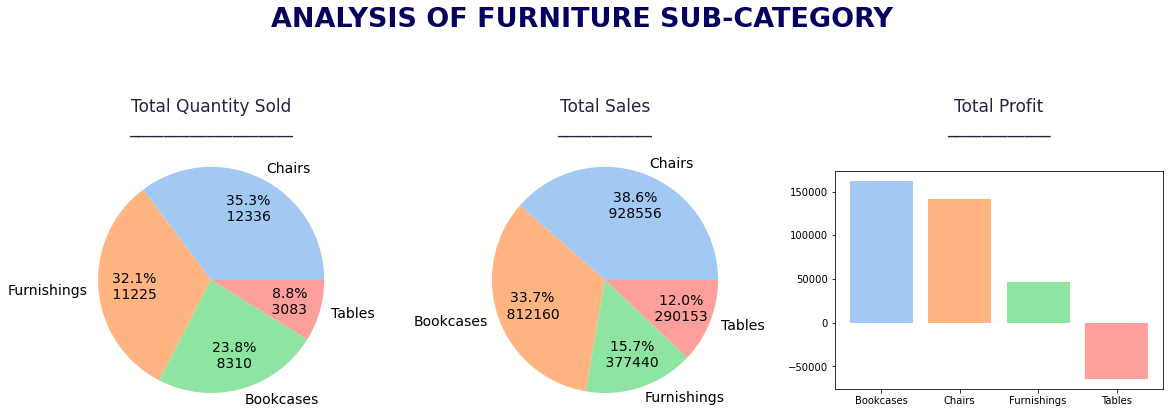

In [13]:
furniture_data = dataset[dataset['category'] == 'Furniture']

fig,[ax1,ax2,ax3] = plt.subplots(1,3,figsize=(20,4))

furniture_solds = furniture_data.groupby('sub_category')['quantity'].sum().sort_values(ascending=False)
furniture_sales = furniture_data.groupby('sub_category')['sales'].sum().sort_values(ascending=False)
furniture_profit = furniture_data.groupby('sub_category')['profit'].sum().sort_values(ascending=False)


# for technology orders
pie_profit_sales_quantity_analysis(ax1,furniture_solds,'Quantity Sold')

# for technology Sales
pie_profit_sales_quantity_analysis(ax2,furniture_sales,'Sales')


ax3.bar(furniture_profit.index , furniture_profit.values , color=colors)
ax3.set_title('Total Profit'+'\n' + '_' * len('Total Profit'), fontsize=17 ,  y=1.15 ,c='#242342' , fontweight='normal')

plt.suptitle('ANALYSIS OF FURNITURE SUB-CATEGORY ' , fontsize=27 , y=1.45 , fontweight='bold' , c='#05015e')

plt.show()

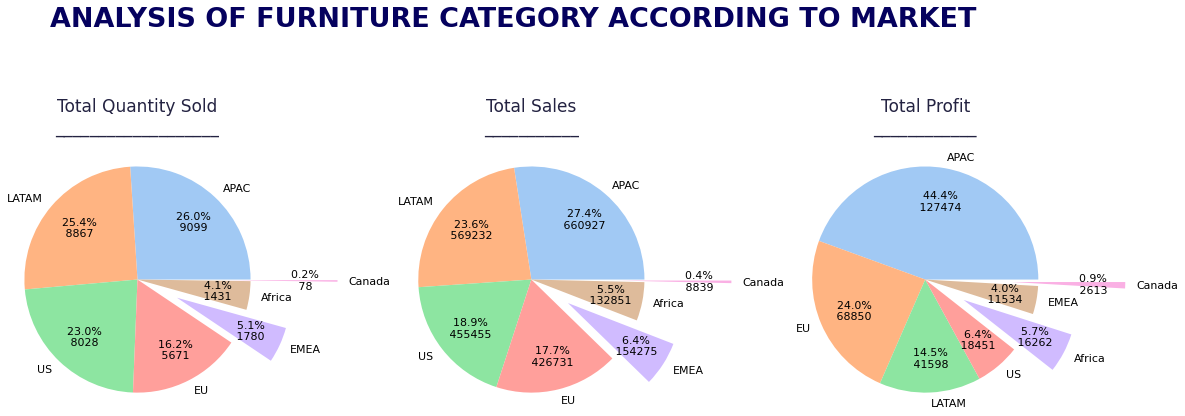

In [14]:
fig,[ax1,ax2,ax3] = plt.subplots(1,3,figsize=(20,4))

furniture_market_solds = furniture_data.groupby('market')['quantity'].sum().sort_values(ascending=False)
furniture_market_sales = furniture_data.groupby('market')['sales'].sum().sort_values(ascending=False)
furniture_market_profit = furniture_data.groupby('market')['profit'].sum().sort_values(ascending=False)


# for technology orders
market_analysis_of_category(ax1,furniture_market_solds,'Quantity Sold')

# for technology Sales
market_analysis_of_category(ax2,furniture_market_sales,'Sales')


# for technology Profit
market_analysis_of_category(ax3,furniture_market_profit,'Profit')



plt.suptitle('ANALYSIS OF FURNITURE CATEGORY ACCORDING TO MARKET' , fontsize=27 , y=1.45 , fontweight='bold' , c='#05015e')

plt.show()

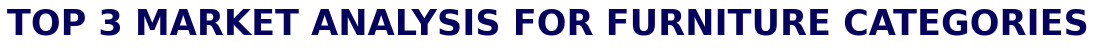

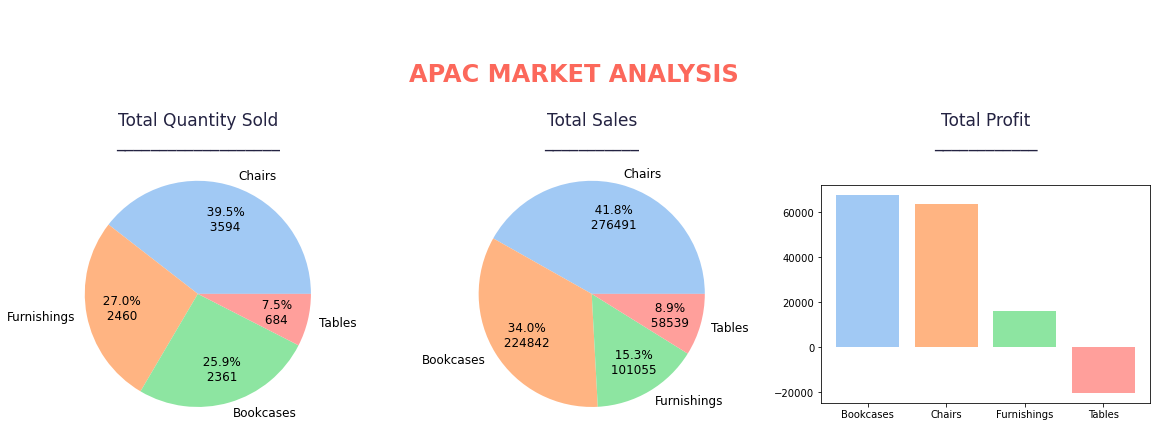

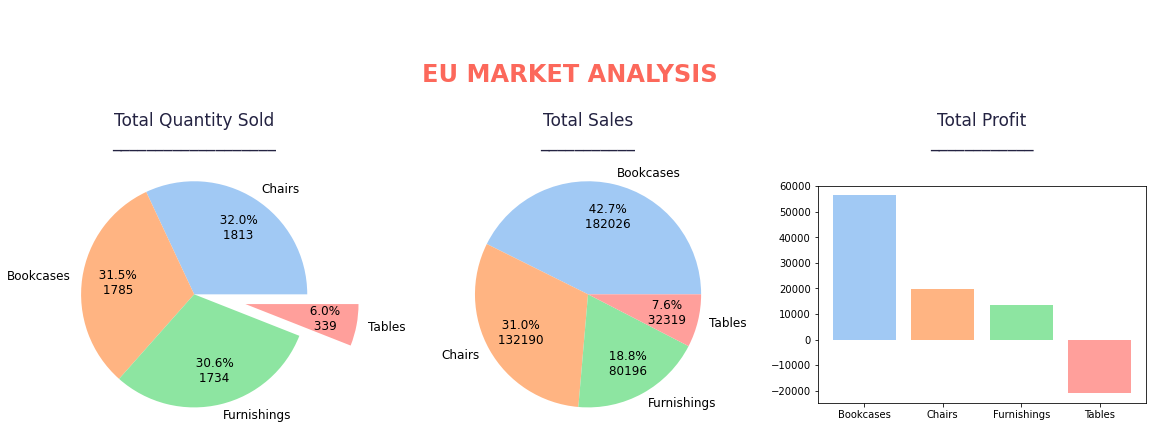

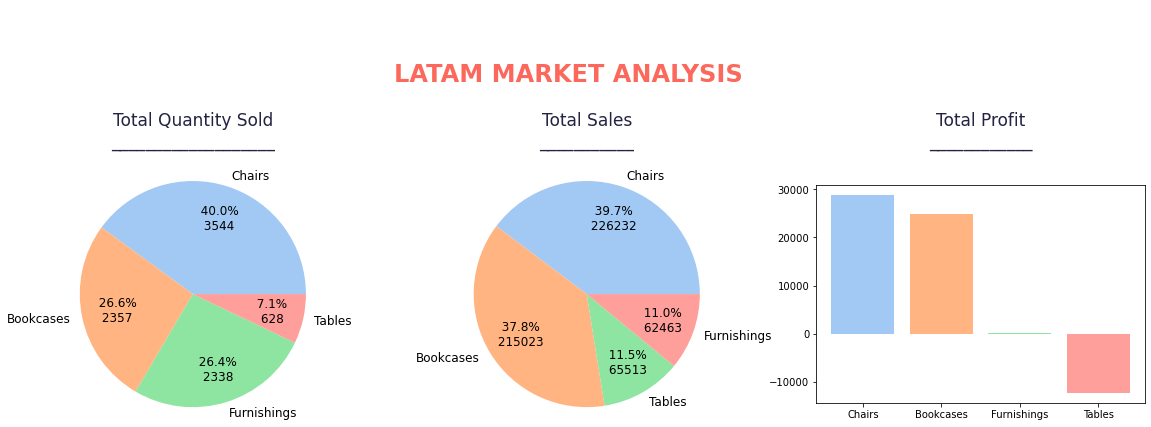

In [15]:

apac_market_furniture_data = furniture_data[furniture_data['market']=='APAC']
eu_market_furniture_data = furniture_data[furniture_data['market']=='EU']
latam_market_furniture_data = furniture_data[furniture_data['market']=='LATAM']

# Add the main title

plt.figure(figsize=(0.01,0.01))
plt.suptitle('TOP 3 MARKET ANALYSIS FOR FURNITURE CATEGORIES', fontsize=35 , y=1.5 , fontweight='bold' , c='#05015e')
plt.axis('off')



# apac market analysis
each_market_analysis(apac_market_furniture_data , 'APAC' , inloss=True)

# eu market analysis
each_market_analysis(eu_market_furniture_data , 'EU', inloss=True)

# latam market analysis
each_market_analysis(latam_market_furniture_data , 'LATAM', inloss=True)


plt.show()

# OFFICE SUPPLY CATEGORY ANALYSIS

TypeError: bar_chart_sales_profit_quantity_analysis() missing 1 required positional argument: 'total_of'

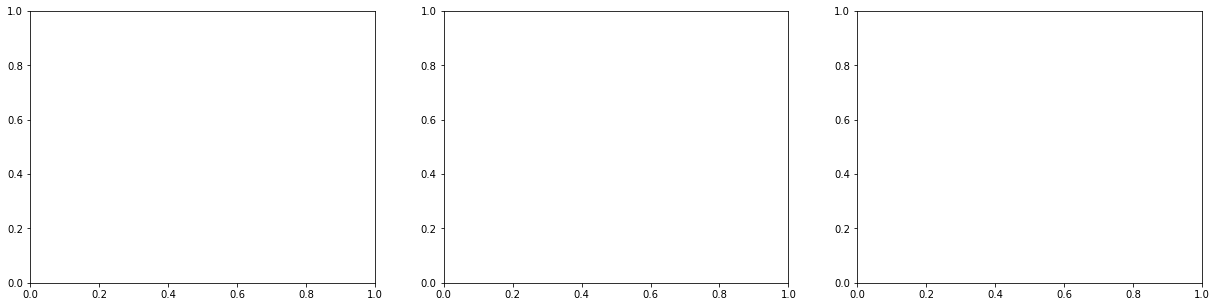

In [16]:
office_supply_data = dataset[dataset['category'] == 'Office Supplies']

fig,[ax1,ax2,ax3] = plt.subplots(1,3,figsize=(21,5))

office_supply_solds = office_supply_data.groupby('sub_category')['quantity'].sum().sort_values(ascending=False)
office_supply_sales =office_supply_data.groupby('sub_category')['sales'].sum().sort_values(ascending=False)
office_supply_profit = office_supply_data.groupby('sub_category')['profit'].sum().sort_values(ascending=False)



bar_chart_sales_profit_quantity_analysis(ax1,office_supply_solds)

bar_chart_sales_profit_quantity_analysis(ax2,office_supply_sales)

bar_chart_sales_profit_quantity_analysis(ax3,office_supply_profit)

plt.suptitle('ANALYSIS OF OFFICE SUPPLY SUB-CATEGORY ' , fontsize=27 , y=1.45 , fontweight='bold' , c='#05015e')

plt.show()

In [ ]:
fig,[ax1,ax2,ax3] = plt.subplots(1,3,figsize=(20,4))

office_supply_market_solds = office_supply_data.groupby('market')['quantity'].sum().sort_values(ascending=False)
office_supply_market_sales = office_supply_data.groupby('market')['sales'].sum().sort_values(ascending=False)
office_supply_market_profit = office_supply_data.groupby('market')['profit'].sum().sort_values(ascending=False)


# for technology orders
market_analysis_of_category(ax1,office_supply_market_solds,'Quantity Sold')

# for technology Sales
market_analysis_of_category(ax2,office_supply_market_sales,'Sales')


# for technology Profit
market_analysis_of_category(ax3,office_supply_market_profit,'Profit')



plt.suptitle('ANALYSIS OF OFFICE SUPPLY CATEGORY ACCORDING TO MARKET' , fontsize=27 , y=1.45 , fontweight='bold' , c='#05015e')

plt.show()

In [ ]:
apac_market_office_supply_data = office_supply_data[office_supply_data['market']=='APAC']
eu_market_office_supply_data = office_supply_data[office_supply_data['market']=='EU']
us_market_office_supply_data = office_supply_data[office_supply_data['market']=='US']

# Add the main title

plt.figure(figsize=(0.01,0.01))
plt.suptitle('TOP 3 MARKET ANALYSIS FOR OFFICE SUPPLY CATEGORIES', fontsize=35 , y=1.5 , fontweight='bold' , c='#05015e')
plt.axis('off')



# apac market analysis
each_market_analysis(apac_market_office_supply_data , 'APAC' , bar=True)

# eu market analysis
each_market_analysis(eu_market_office_supply_data , 'EU', bar=True)

# latam market analysis
each_market_analysis(us_market_office_supply_data , 'US', bar=True)


plt.show()